arousal: -0.17~0.91
intencity: -1.33~6.53


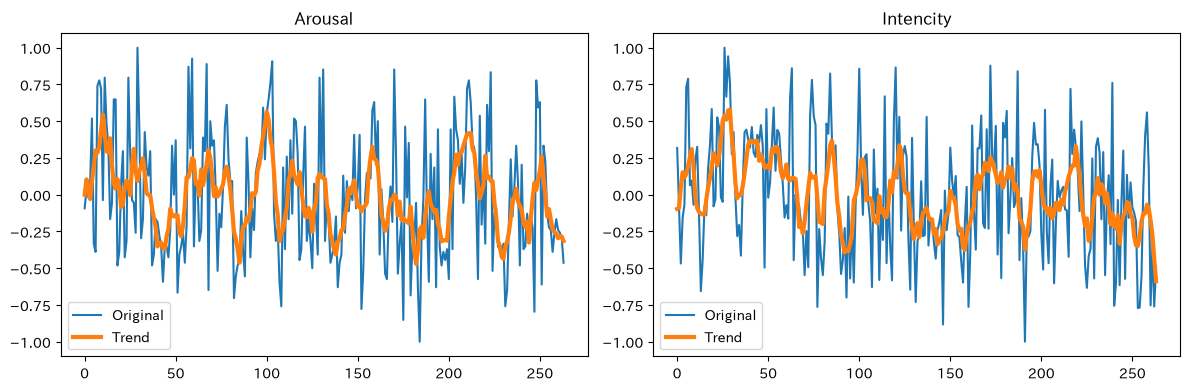

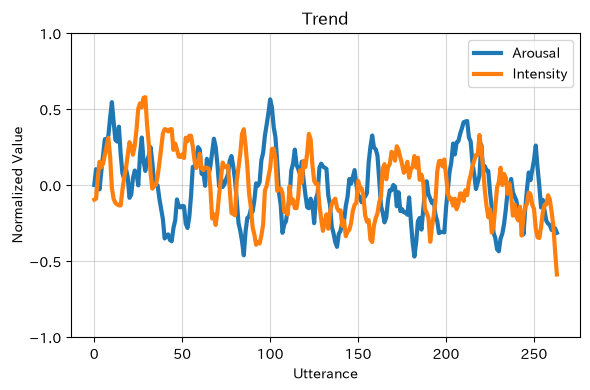

In [ ]:
# Lの移動平均（トレンド）を可視化 win7  (元データのトレンド, arousal, intencity)
# こっちはトレンドを取ると滑らかになる！
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

# 設定
sp = "L"
window = 7      # 5～10くらいで試す

path = f"/home/mitani/CSJ-emo-int_bunseki/0718/0720/LR_bunseki/data/vad_delta_{sp}.csv"
df = pd.read_csv(path)

i_min = df["intensity_pred_kushinada"].min()
i_max = df["intensity_pred_kushinada"].max()
a_min = df["arousal"].min()
a_max = df["arousal"].max()

print(f"arousal: {a_min}~{a_max}")
print(f"intencity: {i_min}~{i_max}")

# pandas.SeriesをNumpy配列に変換
a = df["arousal"].astype(float).values
i = df["intensity_pred_kushinada"].astype(float).values

# 正規化（-1~1）
a = 2 * (a - a.min()) / (a.max() - a.min()) - 1
i = 2 * (i - i.min()) / (i.max() - i.min()) - 1

a_trend = pd.Series(a).rolling(
    window,
    center=True,
    min_periods=1
).mean().values

i_trend = pd.Series(i).rolling(
    window,
    center=True,
    min_periods=1
).mean().values

# 可視化
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharex=True)

# Arousal
axes[0].plot(a, label="Original")
axes[0].plot(a_trend, linewidth=3, label="Trend")
axes[0].set_title("Arousal")
axes[0].legend()

# intencity
axes[1].plot(i, label="Original")
axes[1].plot(i_trend, linewidth=3, label="Trend")
axes[1].set_title("Intencity")
axes[1].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))

plt.plot(a_trend, color="tab:blue", linewidth=3, label="Arousal")
plt.plot(i_trend, color="tab:orange", linewidth=3, label="Intensity")

plt.title("Trend")
plt.xlabel("Utterance")
plt.ylabel("Normalized Value")

ymin = min(a_trend.min(), i_trend.min())
ymax = max(a_trend.max(), i_trend.max())

plt.ylim(ymin, ymax)

# （任意）目盛りを見やすくする
plt.yticks([-1, -0.5, 0, 0.5, 1])

plt.legend()
plt.tight_layout()
plt.grid(alpha=0.5)
plt.show()

=== 正規化前 ===
ΔArousal : mean=-0.0008, std=0.2786
ΔIntensity: mean=-0.0122, std=1.9424

=== Z-score正規化後 ===
ΔArousal : mean=0.0000, std=1.0000
ΔIntensity: mean=-0.0000, std=1.0000

=== トレンド ===
ΔArousal : mean=0.0002, std=0.1740
ΔIntensity: mean=0.0002, std=0.1760


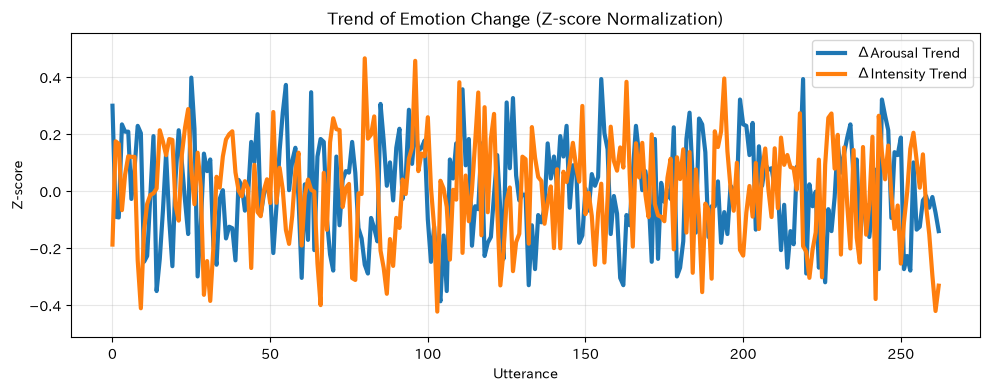

In [ ]:
# 変化量のトレンド(delta_arousal, delta_intencity)
# こっちはトレンドを取るとギザギザになる！
# arousalとintencityでは単位が異なるから、Z-score正規化版をしてスケールを合わせる！(絶対値なし)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

# ==========================
# 設定
# ==========================
sp = "L"
window = 7

path = f"/home/mitani/CSJ-emo-int_bunseki/0718/0720/LR_bunseki/data/vad_delta_{sp}_no_abs.csv"
df = pd.read_csv(path)

# ==========================
# Δデータ
# ==========================
da = df["delta_arousal"].dropna().to_numpy()
di = df["delta_int_kushinada"].dropna().to_numpy()

print("=== 正規化前 ===")
print(f"ΔArousal : mean={da.mean():.4f}, std={da.std():.4f}")
print(f"ΔIntensity: mean={di.mean():.4f}, std={di.std():.4f}")

# ==========================
# Z-score正規化
# ==========================
da = (da - da.mean()) / da.std()
di = (di - di.mean()) / di.std()

print("\n=== Z-score正規化後 ===")
print(f"ΔArousal : mean={da.mean():.4f}, std={da.std():.4f}")
print(f"ΔIntensity: mean={di.mean():.4f}, std={di.std():.4f}")

# ==========================
# トレンド（移動平均）
# ==========================
da_trend = pd.Series(da).rolling(
    window=window,
    center=True,
    min_periods=1
).mean().to_numpy()

di_trend = pd.Series(di).rolling(
    window=window,
    center=True,
    min_periods=1
).mean().to_numpy()

# ==========================
# トレンドの統計量
# ==========================
print("\n=== トレンド ===")
print(f"ΔArousal : mean={da_trend.mean():.4f}, std={da_trend.std():.4f}")
print(f"ΔIntensity: mean={di_trend.mean():.4f}, std={di_trend.std():.4f}")

# ==========================
# 可視化
# ==========================
plt.figure(figsize=(10, 4))

plt.plot(
    da_trend,
    color="tab:blue",
    linewidth=3,
    label="ΔArousal Trend"
)

plt.plot(
    di_trend,
    color="tab:orange",
    linewidth=3,
    label="ΔIntensity Trend"
)

plt.xlabel("Utterance")
plt.ylabel("Z-score")
plt.title("Trend of Emotion Change (Z-score Normalization)")

# 両系列が収まる範囲に表示
ymin = min(da_trend.min(), di_trend.min())
ymax = max(da_trend.max(), di_trend.max())
margin = 0.1 * (ymax - ymin)

plt.ylim(ymin - margin, ymax + margin)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# v,a,dとintencityの相関係数
import pandas as pd
import numpy as np

path = f"/home/mitani/CSJ-emo-int_bunseki/0718/0720/LR_bunseki/data/vad_delta_{sp}.csv"
df = pd.read_csv(path)

# pandas.SeriesをNumpy配列に変換
a = df["arousal"].astype(float).values
v = df["valence"].astype(float).values
d = df["dominance"].astype(float).values
i = df["intensity_pred_kushinada"].astype(float).values

ai = np.corrcoef(a, i)[0,1]
vi = np.corrcoef(v, i)[0,1]
di = np.corrcoef(d, i)[0,1]
print(f"ai={ai}")
print(f"vi={vi}")
print(f"di={di}")

ai=-0.2028489727296383
vi=-0.03204044890278096
di=-0.25968076052997047


In [2]:
import pandas as pd
sp = "L"

# csv 読み込み
df = pd.read_csv(f"/home/mitani/CSJ-emo-int_bunseki/0718/0720/LR_bunseki/data/vad_delta_{sp}.csv")

# 必要な列だけ選択
cols = ['valence', 'arousal', 'dominance', 'intensity_pred_kushinada']
df_sub = df[cols]

# ピアソン相関係数
corr = df_sub.corr(method='pearson')

# print(corr['intensity'])
print(corr)

                           valence   arousal  dominance  \
valence                   1.000000  0.742562   0.735990   
arousal                   0.742562  1.000000   0.982874   
dominance                 0.735990  0.982874   1.000000   
intensity_pred_kushinada -0.032040 -0.202849  -0.259681   

                          intensity_pred_kushinada  
valence                                  -0.032040  
arousal                                  -0.202849  
dominance                                -0.259681  
intensity_pred_kushinada                  1.000000  


In [1]:
print("h")

h
